In [97]:
import torch
from torch import nn
import numpy as np
import pandas as pd

In [98]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [99]:
torch.manual_seed(42)

In [100]:
torch.cuda.manual_seed(42)

In [101]:
from sklearn.datasets import make_moons

n_samples = 2000
X,y = make_moons(n_samples = n_samples,
                 noise = 0.03,
                 random_state = 42)

circles = pd.DataFrame({
            "X1" : X[:,0],
            "X2" : X[:,1],
            "label" : y
         })

circles.head()

,X1,X2,label
0,1.867135,0.111494,1
1,0.430548,0.906135,0
2,0.498592,-0.351714,1
3,-0.954321,0.252829,0
4,0.415218,-0.303597,1


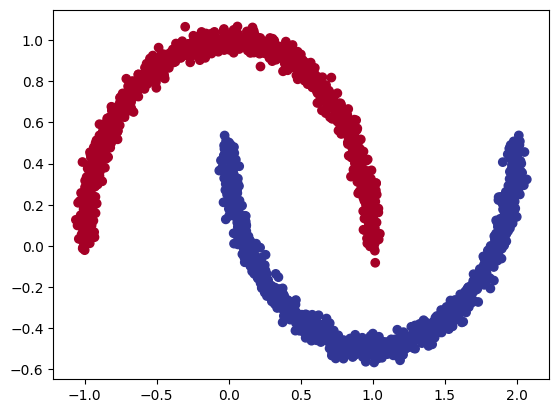

In [102]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu)




In [103]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X,y

(tensor([[ 1.8671,  0.1115],
         [ 0.4305,  0.9061],
         [ 0.4986, -0.3517],
         ...,
         [-0.9151,  0.4547],
         [ 0.8629, -0.5321],
         [ 0.0998,  0.1079]]),
 tensor([1., 0., 1.,  ..., 0., 1., 1.]))

In [104]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size = 0.2,
                                                 random_state = 42)

len(X_train),len(X_test)


(1600, 400)

In [105]:
class MoonModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features =2,out_features=10)
        self.layer_2 = nn.Linear(in_features =10, out_features = 10)
        self.layer_3 = nn.Linear(in_features=10,out_features =10)
        self.layer_4 = nn.Linear(in_features = 10,out_features=1)
        self.relu = nn.ReLU()

    def forward(self,x):

        return self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))



In [106]:
model_0 = MoonModelV0().to(device)

model_0

MoonModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=10, bias=True)
  (layer_4): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [107]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [108]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01)

In [109]:
def accuracy_fn(y_true,y_train):
    correct = torch.eq(y_true,y_train).sum().item()

    return (correct/len(y_true))*100


In [110]:

epochs = 20000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train).squeeze()

    loss = loss_fn(y_pred,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0 :

        model_0.eval()
        with torch.inference_mode():
            y_preds = model_0(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(y_preds))
            
            test_loss = loss_fn(y_preds,y_test)

            accuracy = accuracy_fn(y_test,y_preds)

            print(f"Epochs = {epoch} | Test Loss = {test_loss} | loss = {loss} | acc = {accuracy}")

    





Epochs = 0 | Test Loss = 0.8057616949081421 | loss = 0.6983567476272583 | acc = 50.74999999999999
Epochs = 100 | Test Loss = 0.8057616949081421 | loss = 0.6939147114753723 | acc = 50.74999999999999
Epochs = 200 | Test Loss = 0.8057616949081421 | loss = 0.6903893947601318 | acc = 50.74999999999999
Epochs = 300 | Test Loss = 0.8057616949081421 | loss = 0.6869282126426697 | acc = 50.74999999999999
Epochs = 400 | Test Loss = 0.8057616949081421 | loss = 0.6828945875167847 | acc = 50.74999999999999
Epochs = 500 | Test Loss = 0.7266970872879028 | loss = 0.6776679754257202 | acc = 63.5
Epochs = 600 | Test Loss = 0.5574644804000854 | loss = 0.6705361604690552 | acc = 90.5
Epochs = 700 | Test Loss = 0.5678552985191345 | loss = 0.6602357625961304 | acc = 86.5
Epochs = 800 | Test Loss = 0.5845449566841125 | loss = 0.6458778977394104 | acc = 81.0
Epochs = 900 | Test Loss = 0.5818912982940674 | loss = 0.6263399720191956 | acc = 80.75
Epochs = 1000 | Test Loss = 0.5800895690917969 | loss = 0.59885787

In [111]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


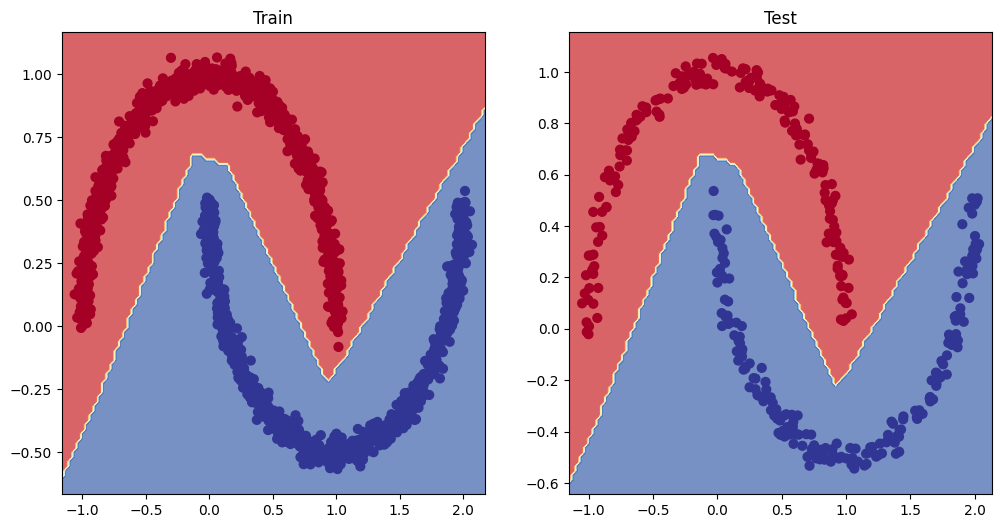

In [112]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [113]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)

MODEL_NAME = "Binary_Classifier_Model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model_0.state_dict(),f =MODEL_SAVE_PATH)